## Libary Import and Data Load

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)

csv_files = [
    "policecalls2022.csv",
    "policecalls2023.csv",
    "policecalls2024.csv",
    "policecalls2025.csv",
    "policecalls2026.csv",
]

df_list = []
for file in csv_files:
    temp = pd.read_csv(file)
    temp["source_file"] = file
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Combined shape:", df.shape)
display(df.head())
df.info()

print("\nColumns:")
print(df.columns.tolist())

print("\nRows by source file:")
display(df["source_file"].value_counts())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

Combined shape: (1170764, 16)


,CDTS,EID,START_DATE,CALL_NUMBER,PRIORITY,REPORT_DATE,OFFENSE_DATE,OFFENSE_TIME,CALLTYPE_CODE,CALL_TYPE,FINAL_DISPO_CODE,FINAL_DISPO,ADDRESS,CITY,STATE,source_file
0,20220101042916PS,8913184,1/1/2022 12:00:00 AM,P220010180,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,02:49:02,1066,SUSPICIOUS PERSON,N,No report required; dispatch record only,[800]-[900] JEANNE AV,San Jose,CA,policecalls2022.csv
1,20220101043036PS,8913196,1/1/2022 12:00:00 AM,P220010191,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,03:05:51,415,DISTURBANCE,N,No report required; dispatch record only,[1500]-[1600] SOUTHWEST EX,San Jose,CA,policecalls2022.csv
2,20220101043827PS,8913252,1/1/2022 12:00:00 AM,P220010236,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,04:35:25,911UNK,UNK TYPE 911 CALL,CAN,Canceled,[4800]-[4900] WESTMONT AV,San Jose,CA,policecalls2022.csv
3,20220101044026PS,8913216,1/1/2022 12:00:00 AM,P220010206,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,03:38:14,SUSCIR,SUSPICIOUS CIRCUMSTANCES,N,No report required; dispatch record only,[3600]-[3700] GREENLEE DR,San Jose,CA,policecalls2022.csv
4,20220102052501PS,8914182,1/1/2022 12:00:00 AM,P220010965,4,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,23:25:49,11300,NARCOTICS,A,Arrest Made,E CAPITOL EX & EVERGREEN PL,San Jose,CA,policecalls2022.csv


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170764 entries, 0 to 1170763
Data columns (total 16 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   CDTS              1170764 non-null  object
 1   EID               1170764 non-null  int64 
 2   START_DATE        1170764 non-null  object
 3   CALL_NUMBER       1170764 non-null  object
 4   PRIORITY          1170764 non-null  int64 
 5   REPORT_DATE       1170764 non-null  object
 6   OFFENSE_DATE      1170764 non-null  object
 7   OFFENSE_TIME      1170764 non-null  object
 8   CALLTYPE_CODE     1170764 non-null  object
 9   CALL_TYPE         1170764 non-null  object
 10  FINAL_DISPO_CODE  1170764 non-null  object
 11  FINAL_DISPO       1170764 non-null  object
 12  ADDRESS           1137620 non-null  object
 13  CITY              1170764 non-null  object
 14  STATE             1170764 non-null  object
 15  source_file       1170764 non-null  object
dtypes: int64(2), objec

source_file
policecalls2022.csv    294515
policecalls2023.csv    286481
policecalls2024.csv    276069
policecalls2025.csv    261724
policecalls2026.csv     51975
Name: count, dtype: int64


Missing values:


ADDRESS             33144
CDTS                    0
START_DATE              0
EID                     0
PRIORITY                0
REPORT_DATE             0
OFFENSE_DATE            0
CALL_NUMBER             0
OFFENSE_TIME            0
CALLTYPE_CODE           0
FINAL_DISPO_CODE        0
CALL_TYPE               0
FINAL_DISPO             0
CITY                    0
STATE                   0
source_file             0
dtype: int64

## Clean and Parse

In [39]:
df["CDTS_clean"] = df["CDTS"].astype(str).str.replace("PS", "", regex=False).str.strip()
df["CDTS"] = pd.to_datetime(df["CDTS_clean"], format="%Y%m%d%H%M%S", errors="coerce")

# Avoid warning + support multiple formats by attempting a list of candidates.
def parse_date_column(column_name):
    fmt_candidates = [
        "%Y%m%d%H%M%S",
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%d %H:%M",
        "%m/%d/%Y %H:%M:%S",
        "%m/%d/%Y",
        "%Y/%m/%d %H:%M:%S",
        "%Y/%m/%d"
    ]
    if column_name in df.columns:
        parsed_column = None
        for fmt in fmt_candidates:
            parsed_fmt = pd.to_datetime(df[column_name], format=fmt, errors="coerce")
            if parsed_fmt.notna().any():
                parsed_column = parsed_fmt
                break

        if parsed_column is None:
            parsed_column = pd.to_datetime(df[column_name], errors="coerce")

        df[column_name] = parsed_column

parse_date_column("START_DATE")
parse_date_column("REPORT_DATE")
parse_date_column("OFFENSE_DATE")

# If any date values are still missing after candidate-format parsing, keep coerce result.
for col in ["START_DATE", "REPORT_DATE", "OFFENSE_DATE"]:
    if col in df.columns and df[col].isna().any():
        df[col] = pd.to_datetime(df[col], errors="coerce")

display(df[["CDTS"]].head())
print("Missing CDTS after parsing:", df["CDTS"].isna().sum())

print("\nRows by parsed year:")
display(df["CDTS"].dt.year.value_counts().sort_index())

C:\Users\evusa\AppData\Local\Temp\ipykernel_22424\735308335.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_column = pd.to_datetime(df[column_name], errors="coerce")
C:\Users\evusa\AppData\Local\Temp\ipykernel_22424\735308335.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_column = pd.to_datetime(df[column_name], errors="coerce")
C:\Users\evusa\AppData\Local\Temp\ipykernel_22424\735308335.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_column = pd.to_datetime(df[column_name], errors="coerce")


,CDTS
0,2022-01-01 04:29:16
1,2022-01-01 04:30:36
2,2022-01-01 04:38:27
3,2022-01-01 04:40:26
4,2022-01-02 05:25:01


Missing CDTS after parsing: 754415

Rows by parsed year:


CDTS
2022.0    95867
2023.0    95653
2024.0    93366
2025.0    87296
2026.0    44167
Name: count, dtype: int64

## Clean the key analysis Columns

In [40]:
df["PRIORITY"] = pd.to_numeric(df["PRIORITY"], errors="coerce")
df["FINAL_DISPO"] = df["FINAL_DISPO"].astype(str).str.strip()
df["CALL_TYPE"] = df["CALL_TYPE"].astype(str).str.strip()

df = df.dropna(subset=["CDTS", "PRIORITY"]).copy()
df = df.sort_values("CDTS").reset_index(drop=True)

print("Cleaned shape:", df.shape)

print("\nPriority distribution:")
display(df["PRIORITY"].value_counts().sort_index())

print("\nTop FINAL_DISPO values:")
display(df["FINAL_DISPO"].value_counts().head(20))

print("\nTop CALL_TYPE values:")
display(df["CALL_TYPE"].value_counts().head(20))

print("\nRows by source file after cleaning:")
display(df["source_file"].value_counts())

print("\nRows by year after cleaning:")
display(df["CDTS"].dt.year.value_counts().sort_index())

Cleaned shape: (416349, 17)

Priority distribution:


PRIORITY
1     12990
2    129095
3    147766
4     44466
5     28460
6     53572
Name: count, dtype: int64


Top FINAL_DISPO values:


FINAL_DISPO
No report required; dispatch record only            192190
Canceled                                             80404
Report taken                                         56849
Gone on Arrival/unable to locate                     17252
No Disposition                                       14561
Traffic Citation Issued, Non-Hazardous Violation      8235
Arrest Made                                           8182
Supplemental report taken                             7638
Traffic Citation Issued, Hazardous Violation          7492
Unfounded event                                       5967
Courtesy Service/Citizen or agency assist             4709
Turned over To (TOT)                                  4019
Criminal Citation                                     3469
Arrest by Warrant                                     2895
Field Interview (F.I.) Completed                      1324
No Response                                           1072
Stranded motorist assist                    


Top CALL_TYPE values:


CALL_TYPE
VEHICLE STOP                         45368
DISTURBANCE                          37260
WELFARE CHECK                        32855
ALARM, AUDIBLE                       30665
PARKING VIOLATION                    19850
DISTURBANCE, FAMILY                  13249
SUSPICIOUS PERSON                    12724
TRESPASSING                          12272
SUSPICIOUS VEHICLE                   11908
STOLEN VEHICLE                       11435
DISTURBANCE, MUSIC                   11056
UNK TYPE 911 CALL                    10625
SUSPICIOUS CIRCUMSTANCES             10185
THEFT                                 8320
RECKLESS DRIVING                      7970
VEHICLE ACCIDENT, PROPERTY DAMAGE     7768
RECOVERED STOLEN VEHICLE              6446
WELFARE CHECK (COMBINED EVENT)        6340
TRAFFIC HAZARD                        6332
MEET THE CITIZEN                      6269
Name: count, dtype: int64


Rows by source file after cleaning:


source_file
policecalls2022.csv    95909
policecalls2023.csv    95663
policecalls2024.csv    93364
policecalls2025.csv    87282
policecalls2026.csv    44131
Name: count, dtype: int64


Rows by year after cleaning:


CDTS
2022    95867
2023    95653
2024    93366
2025    87296
2026    44167
Name: count, dtype: int64

## Create time-based features

In [41]:
df["year"] = df["CDTS"].dt.year
df["month"] = df["CDTS"].dt.month
df["day"] = df["CDTS"].dt.date
df["hour"] = df["CDTS"].dt.hour
df["day_of_week"] = df["CDTS"].dt.day_name()
df["is_weekend"] = df["CDTS"].dt.dayofweek >= 5

display(df[["CDTS", "year", "month", "day", "hour", "day_of_week", "is_weekend"]].head())

,CDTS,year,month,day,hour,day_of_week,is_weekend
0,2022-01-01 00:03:07,2022,1,2022-01-01,0,Saturday,True
1,2022-01-01 00:03:54,2022,1,2022-01-01,0,Saturday,True
2,2022-01-01 00:06:18,2022,1,2022-01-01,0,Saturday,True
3,2022-01-01 00:08:03,2022,1,2022-01-01,0,Saturday,True
4,2022-01-01 00:11:15,2022,1,2022-01-01,0,Saturday,True


## Creating flags for canceled calls and priority groups

In [42]:
df["FINAL_DISPO_upper"] = df["FINAL_DISPO"].str.upper()
df["is_canceled"] = df["FINAL_DISPO_upper"].str.contains("CANCEL", na=False)

df["is_p1"] = df["PRIORITY"] == 1
df["is_p3_p4"] = df["PRIORITY"].isin([3, 4])
df["is_canceled_p3_p4"] = df["is_canceled"] & df["is_p3_p4"]

display(df[["PRIORITY", "FINAL_DISPO", "is_canceled", "is_p1", "is_p3_p4", "is_canceled_p3_p4"]].head())

,PRIORITY,FINAL_DISPO,is_canceled,is_p1,is_p3_p4,is_canceled_p3_p4
0,4,Canceled,True,False,True,True
1,2,Canceled,True,False,False,False
2,4,Canceled,True,False,True,True
3,4,Canceled,True,False,True,True
4,6,No report required; dispatch record only,False,False,False,False


## basic descriptive EDA

In [43]:
daily_calls = df.groupby("day").size().reset_index(name="total_calls")
hourly_calls = df.groupby("hour").size().reset_index(name="total_calls")

priority_counts = df["PRIORITY"].value_counts().sort_index().reset_index()
priority_counts.columns = ["PRIORITY", "count"]

cancel_by_priority = (
    df.groupby("PRIORITY")
      .agg(
          total_calls=("PRIORITY", "size"),
          canceled_calls=("is_canceled", "sum"),
          canceled_p3_p4=("is_canceled_p3_p4", "sum")
      )
      .reset_index()
)

cancel_by_priority["cancel_rate"] = cancel_by_priority["canceled_calls"] / cancel_by_priority["total_calls"]

display(daily_calls.head())
display(hourly_calls.head())
display(priority_counts)
display(cancel_by_priority)

,day,total_calls
0,2022-01-01,794
1,2022-01-02,726
2,2022-01-03,804
3,2022-01-04,796
4,2022-01-05,848


,hour,total_calls
0,0,22277
1,1,17742
2,2,13632
3,3,10565
4,4,8718


,PRIORITY,count
0,1,12990
1,2,129095
2,3,147766
3,4,44466
4,5,28460
5,6,53572


,PRIORITY,total_calls,canceled_calls,canceled_p3_p4,cancel_rate
0,1,12990,650,0,0.050038
1,2,129095,20920,0,0.162051
2,3,147766,40922,40922,0.276938
3,4,44466,17160,17160,0.385913
4,5,28460,232,0,0.008152
5,6,53572,520,0,0.009707


## Plot the basic desc patterns

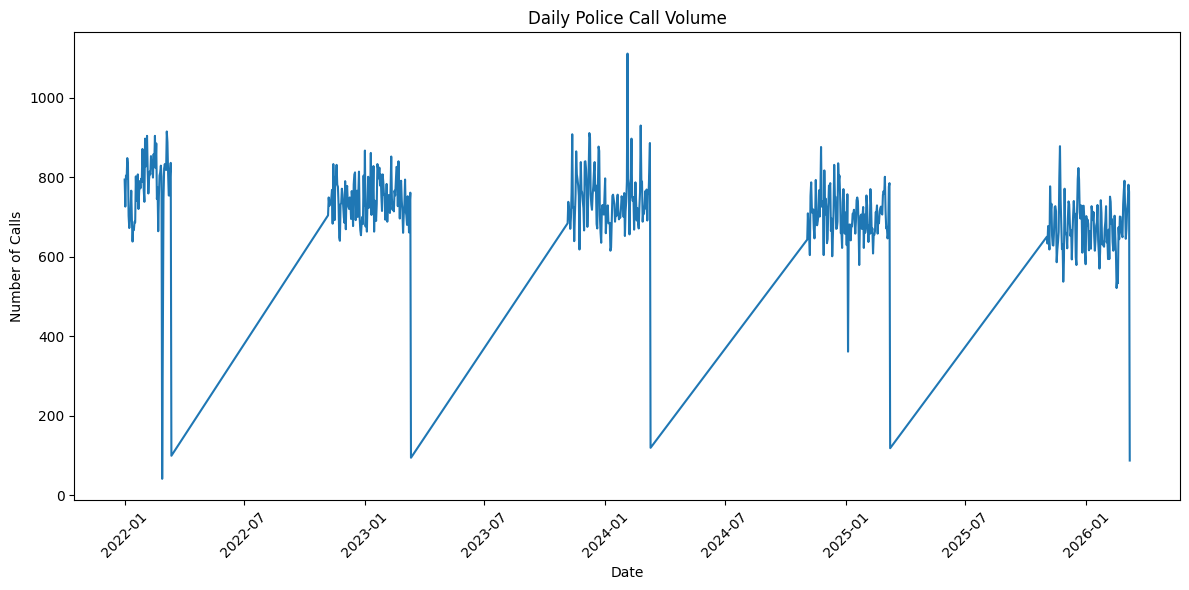

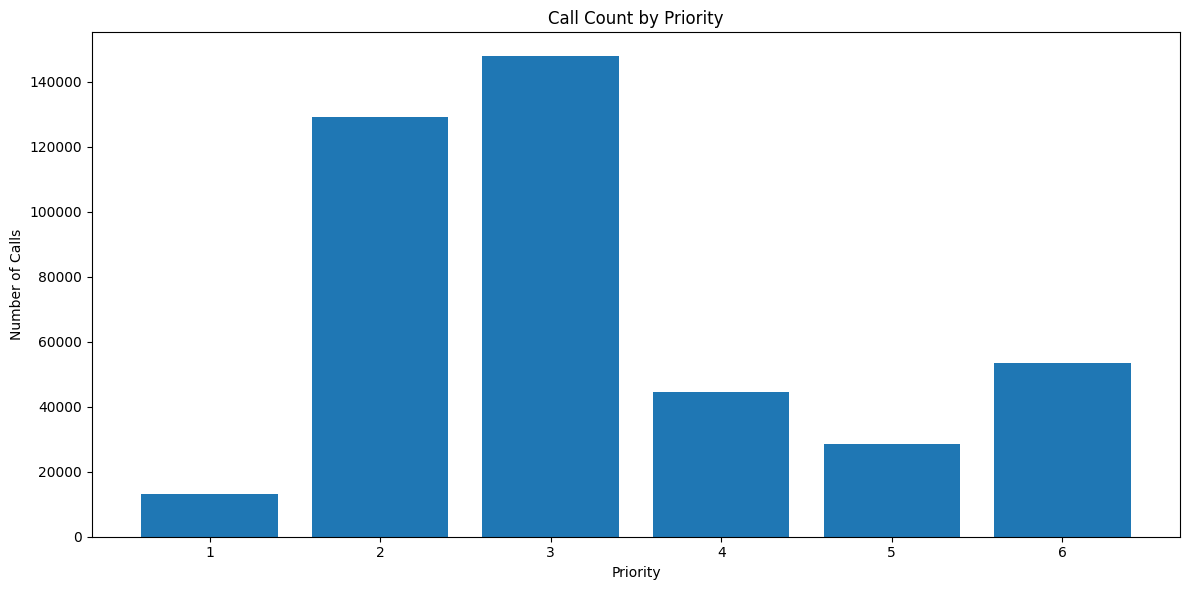

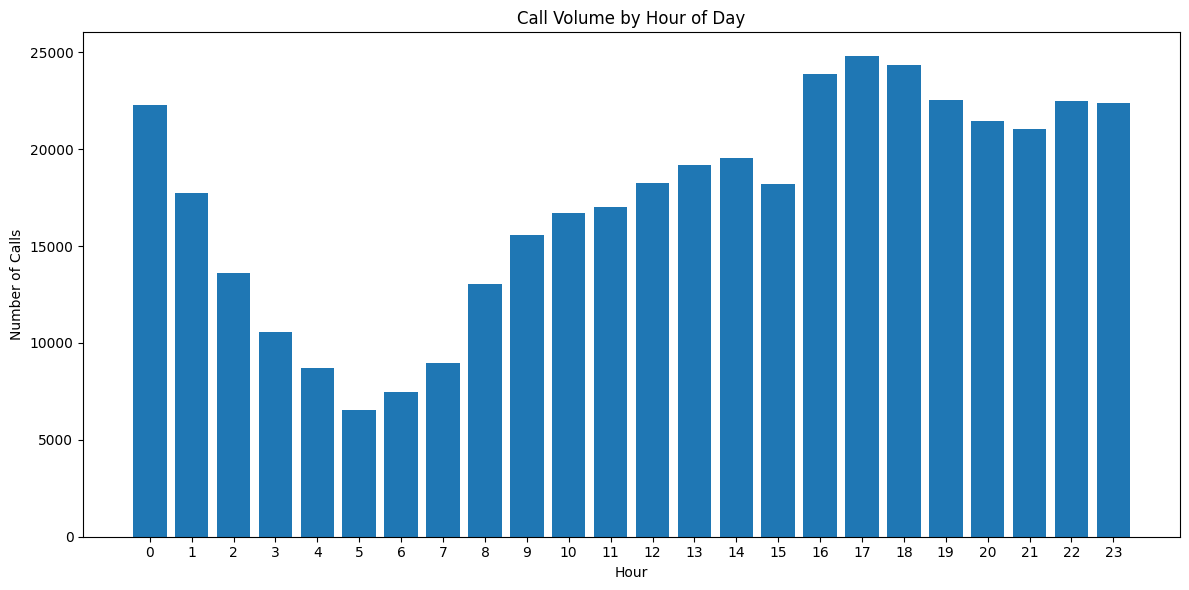

In [44]:
plt.figure()
plt.plot(daily_calls["day"], daily_calls["total_calls"])
plt.title("Daily Police Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(priority_counts["PRIORITY"].astype(str), priority_counts["count"])
plt.title("Call Count by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(hourly_calls["hour"].astype(str), hourly_calls["total_calls"])
plt.title("Call Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

## Examine when canceled lower-prio calls happen

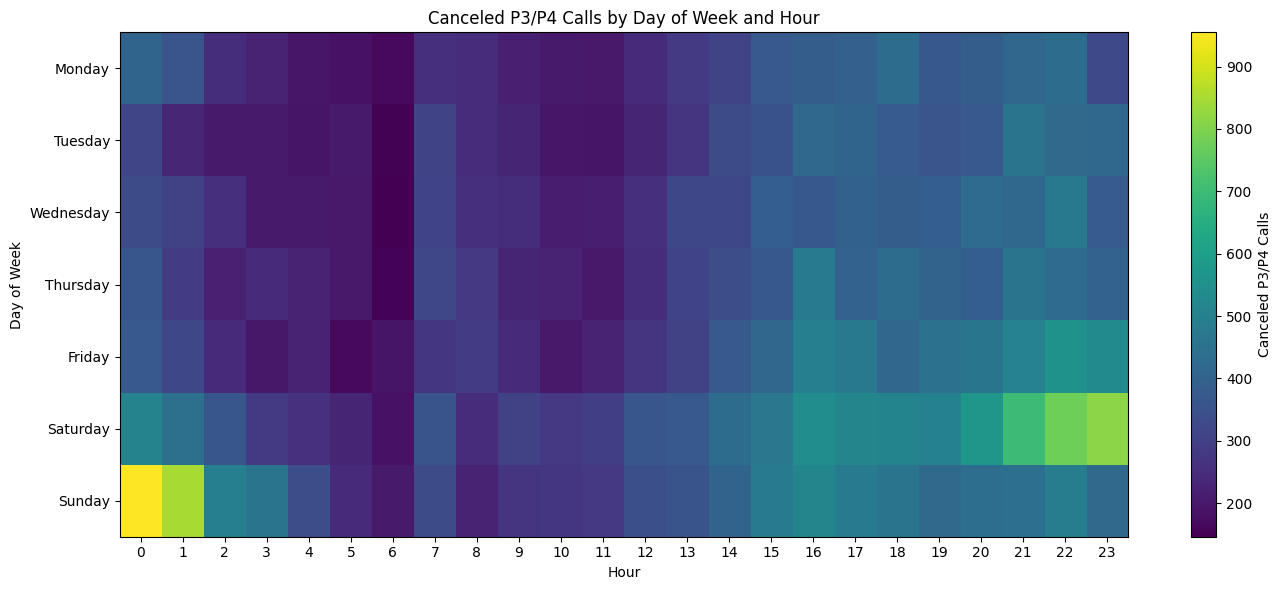

In [45]:
cancel_heat = (
    df.groupby(["day_of_week", "hour"])["is_canceled_p3_p4"]
      .sum()
      .unstack(fill_value=0)
)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
cancel_heat = cancel_heat.reindex(day_order)

plt.figure(figsize=(14, 6))
plt.imshow(cancel_heat, aspect="auto")
plt.colorbar(label="Canceled P3/P4 Calls")
plt.title("Canceled P3/P4 Calls by Day of Week and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.xticks(range(24), range(24))
plt.yticks(range(len(cancel_heat.index)), cancel_heat.index)
plt.tight_layout()
plt.show()

## Aggregate the data into a stress table

In [46]:
# Create short time windows for stress analysis
# This is the critical fix: time_bin must exist before grouping by it.
time_bin_size = "5min"
df["time_bin"] = df["CDTS"].dt.floor(time_bin_size)

display(df[["CDTS", "time_bin"]].head())

agg = (
    df.groupby("time_bin")
      .apply(
          lambda g: pd.Series({
              "total_calls": len(g),
              "p1_calls": (g["PRIORITY"] == 1).sum(),
              "p3_p4_calls": g["PRIORITY"].isin([3, 4]).sum(),
              "canceled_p3_p4": (g["is_canceled"] & g["PRIORITY"].isin([3, 4])).sum(),
              "all_canceled": g["is_canceled"].sum()
          })
      )
      .reset_index()
)

agg["cancel_rate_p3_p4"] = np.where(
    agg["p3_p4_calls"] > 0,
    agg["canceled_p3_p4"] / agg["p3_p4_calls"],
    np.nan
)

agg["has_p1"] = agg["p1_calls"] > 0

display(agg.head())
display(agg.describe(include="all"))

,CDTS,time_bin
0,2022-01-01 00:03:07,2022-01-01 00:00:00
1,2022-01-01 00:03:54,2022-01-01 00:00:00
2,2022-01-01 00:06:18,2022-01-01 00:05:00
3,2022-01-01 00:08:03,2022-01-01 00:05:00
4,2022-01-01 00:11:15,2022-01-01 00:10:00


C:\Users\evusa\AppData\Local\Temp\ipykernel_22424\3156236697.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,time_bin,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,all_canceled,cancel_rate_p3_p4,has_p1
0,2022-01-01 00:00:00,2,0,1,1,2,1.0,False
1,2022-01-01 00:05:00,2,0,2,2,2,1.0,False
2,2022-01-01 00:10:00,2,0,1,1,1,1.0,False
3,2022-01-01 00:15:00,1,0,1,1,1,1.0,False
4,2022-01-01 00:20:00,2,0,2,2,2,1.0,False


,time_bin,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,all_canceled,cancel_rate_p3_p4,has_p1
count,143698,143698.000000,143698.000000,143698.000000,143698.000000,143698.000000,106597.000000,143698
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,131332
mean,2024-03-17 02:16:52.734345472,2.897389,0.090398,1.337750,0.404195,0.559535,0.293280,NaN
min,2022-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2023-01-17 15:06:15,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,2024-02-01 20:07:30,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
75%,2025-02-17 13:43:45,4.000000,0.000000,2.000000,1.000000,1.000000,0.500000,NaN
max,2026-03-08 01:50:00,19.000000,4.000000,17.000000,17.000000,17.000000,1.000000,NaN


## Compare Prio 1 activity against canceled lower-prio calls

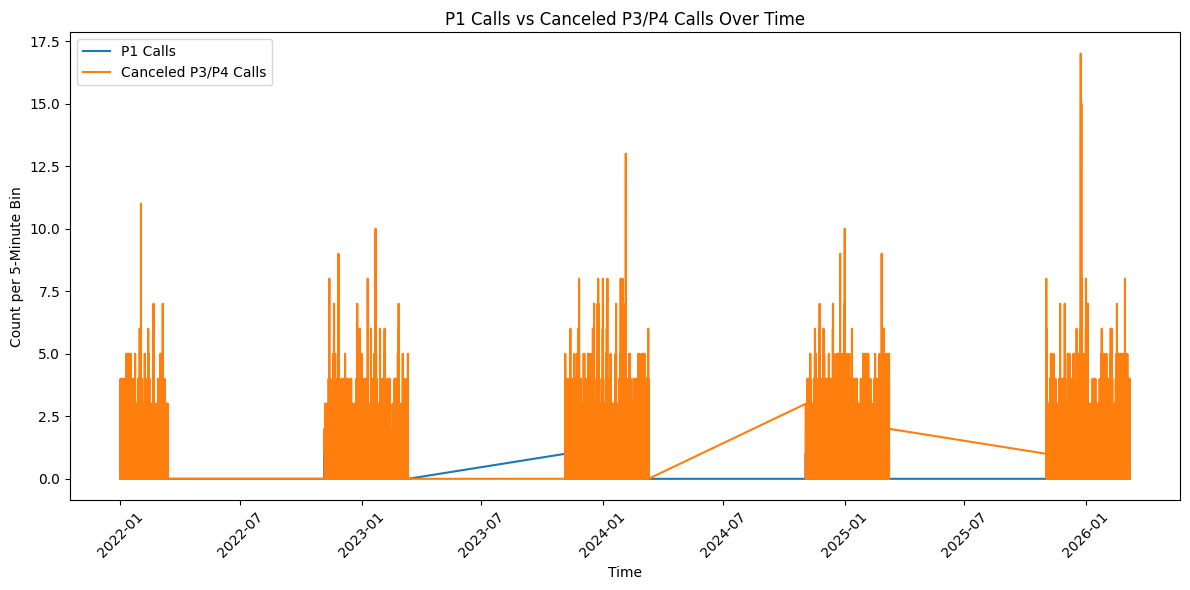

In [47]:
plt.figure()
plt.plot(agg["time_bin"], agg["p1_calls"], label="P1 Calls")
plt.plot(agg["time_bin"], agg["canceled_p3_p4"], label="Canceled P3/P4 Calls")
plt.title("P1 Calls vs Canceled P3/P4 Calls Over Time")
plt.xlabel("Time")
plt.ylabel("Count per 5-Minute Bin")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Compare window with and without P1 calls

In [48]:
p1_compare = (
    agg.groupby("has_p1")
       .agg(
           bins=("time_bin", "count"),
           avg_p1_calls=("p1_calls", "mean"),
           avg_canceled_p3_p4=("canceled_p3_p4", "mean"),
           avg_cancel_rate_p3_p4=("cancel_rate_p3_p4", "mean")
       )
       .reset_index()
)

display(p1_compare)

,has_p1,bins,avg_p1_calls,avg_canceled_p3_p4,avg_cancel_rate_p3_p4
0,False,131332,0.000000,0.404844,0.292940
1,True,12366,1.050461,0.397299,0.297232


## Search for the breaking point

,p1_bin,num_bins,avg_canceled_p3_p4,avg_cancel_rate_p3_p4,median_cancel_rate_p3_p4
0,0,131332,0.404844,0.292940,0.0
1,1,11773,0.395651,0.296959,0.0
2,2,564,0.437943,0.312412,0.0
3,3,27,0.296296,0.122727,0.0
4,4+,2,0.000000,NaN,NaN


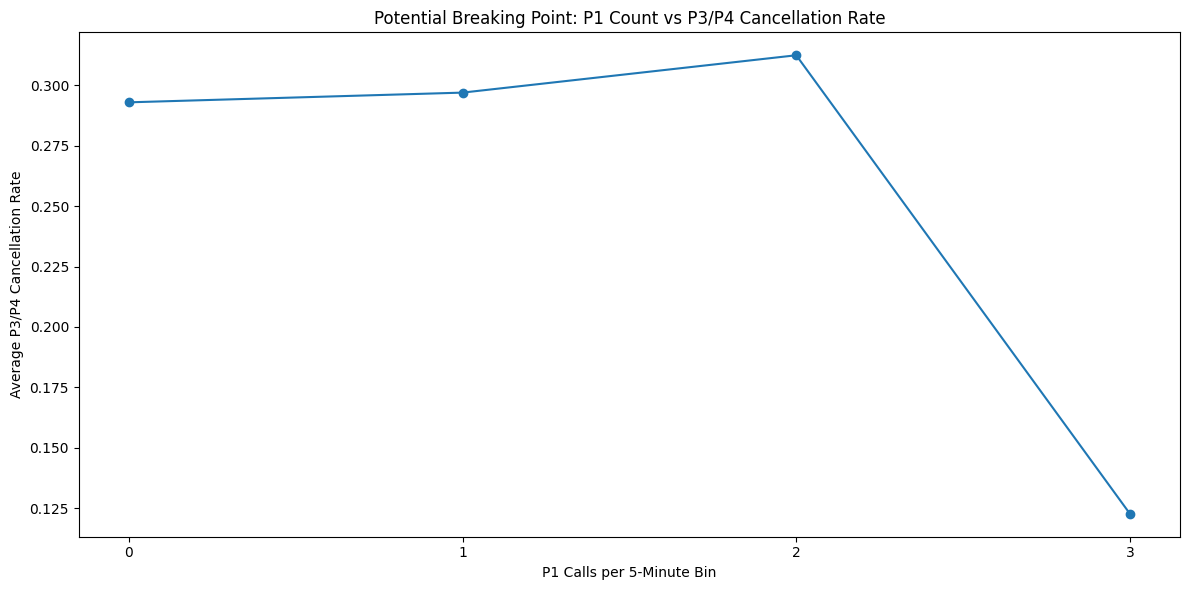

In [49]:
agg["p1_bin"] = pd.cut(
    agg["p1_calls"],
    bins=[-1, 0, 1, 2, 3, 100],
    labels=["0", "1", "2", "3", "4+"]
)

breaking_point = (
    agg.groupby("p1_bin", observed=False)
       .agg(
           num_bins=("time_bin", "count"),
           avg_canceled_p3_p4=("canceled_p3_p4", "mean"),
           avg_cancel_rate_p3_p4=("cancel_rate_p3_p4", "mean"),
           median_cancel_rate_p3_p4=("cancel_rate_p3_p4", "median")
       )
       .reset_index()
)

display(breaking_point)

plt.figure()
plt.plot(breaking_point["p1_bin"].astype(str), breaking_point["avg_cancel_rate_p3_p4"], marker="o")
plt.title("Potential Breaking Point: P1 Count vs P3/P4 Cancellation Rate")
plt.xlabel("P1 Calls per 5-Minute Bin")
plt.ylabel("Average P3/P4 Cancellation Rate")
plt.tight_layout()
plt.show()

## Compute simple relationship measures

In [50]:
prob_with_p1 = agg.loc[agg["has_p1"], "cancel_rate_p3_p4"].mean()
prob_without_p1 = agg.loc[~agg["has_p1"], "cancel_rate_p3_p4"].mean()

print("Average P3/P4 cancellation rate when there is at least one P1 call:", prob_with_p1)
print("Average P3/P4 cancellation rate when there are no P1 calls:", prob_without_p1)

corr_value = agg[["p1_calls", "canceled_p3_p4"]].corr().iloc[0, 1]
print("Correlation between P1 calls and canceled P3/P4 calls:", corr_value)

Average P3/P4 cancellation rate when there is at least one P1 call: 0.29723155348512376
Average P3/P4 cancellation rate when there are no P1 calls: 0.2929400682057249
Correlation between P1 calls and canceled P3/P4 calls: -0.0024170911404780776


## Find top stress windows for case studies

In [51]:
top_stress_windows = agg.sort_values(
    ["canceled_p3_p4", "p1_calls", "total_calls"],
    ascending=[False, False, False]
).head(20)

display(top_stress_windows)

,time_bin,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,all_canceled,cancel_rate_p3_p4,has_p1,p1_bin
125583,2025-12-24 04:30:00,17,0,17,17,17,1.000000,False,0
125845,2025-12-25 04:10:00,17,1,16,15,15,0.937500,True,1
72581,2024-02-04 16:25:00,19,1,17,13,13,0.764706,True,1
7831,2022-02-01 00:15:00,13,0,13,11,11,0.846154,False,0
37037,2023-01-22 00:20:00,16,0,12,10,11,0.833333,False,0
125836,2025-12-25 03:25:00,13,0,12,10,10,0.833333,False,0
125809,2025-12-25 00:50:00,12,0,11,10,10,0.909091,False,0
96058,2025-01-01 01:25:00,10,0,10,10,10,1.000000,False,0
22882,2022-11-26 21:15:00,10,0,10,9,9,0.900000,False,0
94305,2024-12-25 01:55:00,10,0,9,9,9,1.000000,False,0


## Inspect one specific event window

In [52]:
if not top_stress_windows.empty:
    selected_window = top_stress_windows.iloc[0]["time_bin"]
    start_window = selected_window - pd.Timedelta(minutes=15)
    end_window = selected_window + pd.Timedelta(minutes=15)

    event_slice = df[(df["CDTS"] >= start_window) & (df["CDTS"] <= end_window)].copy()
    event_slice = event_slice.sort_values("CDTS")

    print("Case study window:", start_window, "to", end_window)
    
    cols_to_show = ["CDTS", "PRIORITY", "CALL_TYPE", "FINAL_DISPO"]
    if "ADDRESS" in event_slice.columns:
        cols_to_show.append("ADDRESS")

    display(event_slice[cols_to_show])

Case study window: 2025-12-24 04:15:00 to 2025-12-24 04:45:00


,CDTS,PRIORITY,CALL_TYPE,FINAL_DISPO,ADDRESS
366922,2025-12-24 04:19:09,3,ALARM,No report required; dispatch record only,[3600]-[3700] PEARL AV
366923,2025-12-24 04:21:02,3,DISTURBANCE,No report required; dispatch record only,[1800]-[1800] STOKES ST
366924,2025-12-24 04:21:07,2,WELFARE CHECK,Report taken,BURTON AV & N 1ST ST
366925,2025-12-24 04:21:38,3,"ALARM, AUDIBLE",No report required; dispatch record only,[1000]-[1100] FOXWORTHY AV
366926,2025-12-24 04:23:40,3,TRAFFIC HAZARD,No Disposition,[1200]-[1300] THORNBURY LN
366927,2025-12-24 04:27:06,3,"ALARM, AUDIBLE",Canceled,[2100]-[2200] MONTEREY RD
366928,2025-12-24 04:27:20,3,"ALARM, AUDIBLE",Canceled,[900]-[1000] OAKLAND RD
366929,2025-12-24 04:28:00,1,EXPLOSION,No report required; dispatch record only,ALMADEN EX & IRONWOOD DR
366930,2025-12-24 04:29:10,3,"ALARM, AUDIBLE",Canceled,[0]-[100] KEYES ST
366931,2025-12-24 04:31:03,3,"ALARM, AUDIBLE",Canceled,[1600]-[1600] SARATOGA AV


## build a yearly and monthly summary

,year,month,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,cancel_rate_p3_p4
0,2022,1,23348,738,9966,2782,0.279149
1,2022,2,21332,635,8507,2282,0.268250
2,2022,3,9908,287,3903,985,0.252370
3,2022,11,18564,583,8030,2221,0.276588
4,2022,12,22715,722,10231,2789,0.272603
5,2023,1,23549,809,10607,2976,0.280569
6,2023,2,21021,674,9645,2648,0.274546
7,2023,3,8048,253,3616,912,0.252212
8,2023,11,19306,569,9067,2804,0.309253
9,2023,12,23729,786,10971,3484,0.317564


,year,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,cancel_rate_p3_p4
0,2022,95867,2965,40637,11059,0.272141
1,2023,95653,3091,43906,12824,0.292079
2,2024,93366,3003,44010,14022,0.318609
3,2025,87296,2687,41738,13144,0.314917
4,2026,44167,1244,21941,7033,0.320541


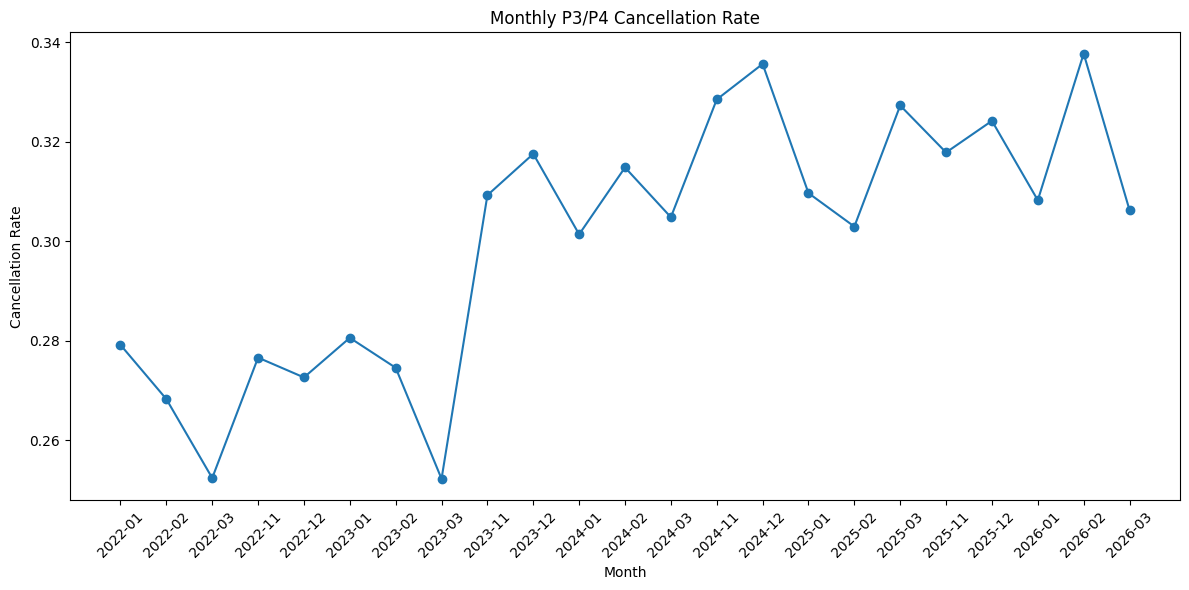

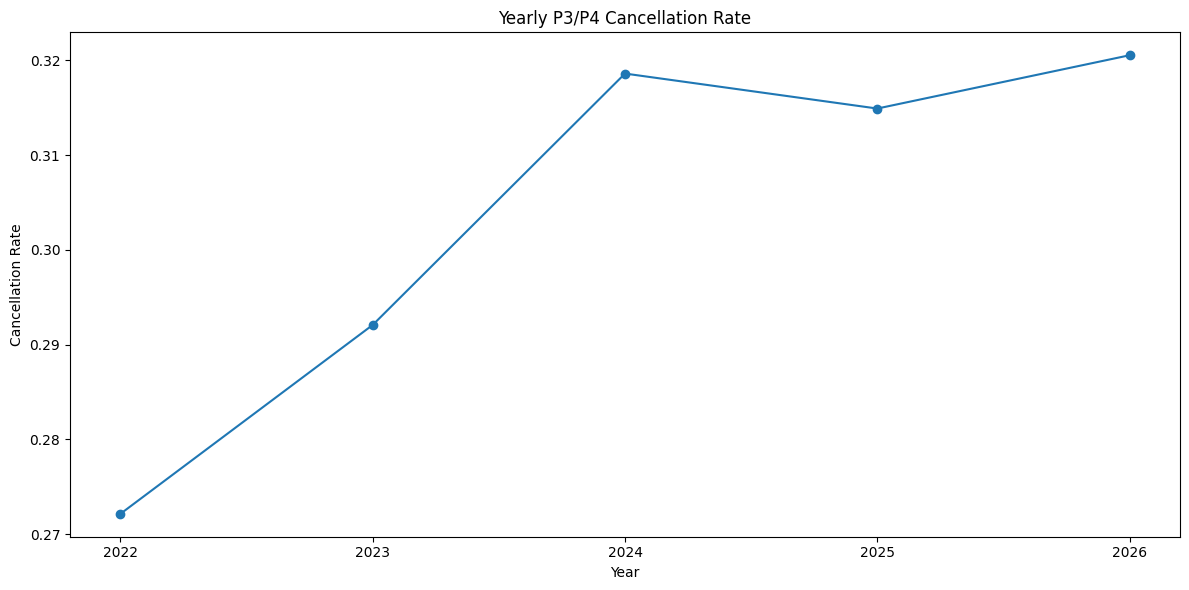

In [53]:
monthly_summary = (
    df.groupby(["year", "month"])
      .agg(
          total_calls=("PRIORITY", "size"),
          p1_calls=("is_p1", "sum"),
          p3_p4_calls=("is_p3_p4", "sum"),
          canceled_p3_p4=("is_canceled_p3_p4", "sum")
      )
      .reset_index()
)

monthly_summary["cancel_rate_p3_p4"] = np.where(
    monthly_summary["p3_p4_calls"] > 0,
    monthly_summary["canceled_p3_p4"] / monthly_summary["p3_p4_calls"],
    np.nan
)

yearly_summary = (
    df.groupby("year")
      .agg(
          total_calls=("PRIORITY", "size"),
          p1_calls=("is_p1", "sum"),
          p3_p4_calls=("is_p3_p4", "sum"),
          canceled_p3_p4=("is_canceled_p3_p4", "sum")
      )
      .reset_index()
)

yearly_summary["cancel_rate_p3_p4"] = np.where(
    yearly_summary["p3_p4_calls"] > 0,
    yearly_summary["canceled_p3_p4"] / yearly_summary["p3_p4_calls"],
    np.nan
)

# Sort before summary display and plotting for correct chronological order
monthly_summary = monthly_summary.sort_values(["year", "month"]).reset_index(drop=True)
yearly_summary = yearly_summary.sort_values("year").reset_index(drop=True)


display(monthly_summary)
display(yearly_summary)

plt.figure()
month_labels = monthly_summary["year"].astype(str) + "-" + monthly_summary["month"].astype(str).str.zfill(2)
plt.plot(month_labels, monthly_summary["cancel_rate_p3_p4"], marker="o")
plt.title("Monthly P3/P4 Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(yearly_summary["year"].astype(str), yearly_summary["cancel_rate_p3_p4"], marker="o")
plt.title("Yearly P3/P4 Cancellation Rate")
plt.xlabel("Year")
plt.ylabel("Cancellation Rate")
plt.tight_layout()
plt.show()

## Print a compact EDA summary

In [54]:
summary_stats = {
    "total_rows_after_cleaning": int(len(df)),
    "date_min": df["CDTS"].min(),
    "date_max": df["CDTS"].max(),
    "total_p1_calls": int(df["is_p1"].sum()),
    "total_p3_p4_calls": int(df["is_p3_p4"].sum()),
    "total_canceled_calls": int(df["is_canceled"].sum()),
    "total_canceled_p3_p4": int(df["is_canceled_p3_p4"].sum()),
    "avg_cancel_rate_with_p1": float(prob_with_p1) if pd.notna(prob_with_p1) else np.nan,
    "avg_cancel_rate_without_p1": float(prob_without_p1) if pd.notna(prob_without_p1) else np.nan,
    "p1_cancel_corr": float(corr_value) if pd.notna(corr_value) else np.nan
}

print("\nEDA Summary Stats")
for k, v in summary_stats.items():
    print(f"{k}: {v}")


EDA Summary Stats
total_rows_after_cleaning: 416349
date_min: 2022-01-01 00:03:07
date_max: 2026-03-08 01:54:28
total_p1_calls: 12990
total_p3_p4_calls: 192232
total_canceled_calls: 80404
total_canceled_p3_p4: 58082
avg_cancel_rate_with_p1: 0.29723155348512376
avg_cancel_rate_without_p1: 0.2929400682057249
p1_cancel_corr: -0.0024170911404780776
